# Sec. 7.2: the verified backend on Gillian's queries

Gillian, run with `--certified-smt`, sends every SMT query to its own encoder
and, through a bridge into CSE's expression syntax, to the encoder extracted
from the Rocq development. `run.sh` runs 32 verification cases this way and
records each query in `queries.jsonl` (see `README.md`).

This notebook reads one such run. By default it reads the paper's (`paper-run/`);
to read your own re-run, set `RUN = "results"` below. The paper's numbers alone
are printed by `python report.py`.

1. Coverage and agreement (Fig. 9's table)
2. Solver time (Fig. 9's scatter plot, and the appendix's timings)
3. The disagreements
4. What does not reach an answer

In [1]:
import json
import re
import shutil
import subprocess
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

import report

RUN = "paper-run"
df, cases, records = report.load_run(RUN)
print(f"{RUN}: {len(df)} queries from {len(cases)} cases")

paper-run: 3507 queries from 32 cases


## 1. Coverage and agreement

A query passes through three stages on the verified side, and each column
counts the queries that passed that stage:

- **translated**: the bridge expressed it in CSE's syntax. Gillian's expression
  language is larger than CSE's; Sec. 4 below shows what is left out.
- **encoded**: the extracted encoder produced SMT-LIB for it.
- **answered**: both backends' solver calls returned `sat` or `unsat`.

**agree** counts the answered queries on which the two backends gave the same
answer.

In [2]:
cov = report.coverage_table(df, cases)
cov["translated %"] = (100 * cov.translated / cov.queries).round(1)
cov["agree %"] = (100 * cov.agree / cov.answered).round(1)
cov

,files,queries,translated,encoded,answered,agree,translated %,agree %
language,,,,,,,,
JS,16,985,788,788,785,778,80.0,99.1
C,7,2099,1980,1638,1094,1094,94.3,100.0
WISL,9,423,418,416,416,416,98.8,100.0
Total,32,3507,3186,2842,2295,2288,90.8,99.7


## 2. Solver time

Check-sat time only, for each query both backends answered: it excludes
building the query and sending the declarations and assertions. Points on the
dashed line took the same time under both encodings.

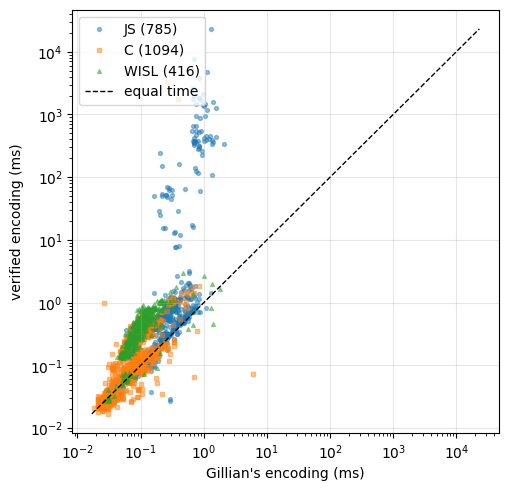

Gillian ms       verified ms        
             median   p95      median     p95
language                                     
JS             0.20  0.82        0.42  375.02
C              0.06  0.21        0.08    0.48
WISL           0.09  0.22        0.40    1.00
Total          0.10  0.57        0.21    1.47

In [3]:
a = df[df.answered]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for lang, marker in [("JS", "o"), ("C", "s"), ("WISL", "^")]:
    d = a[a.language == lang]
    ax.scatter(d.u_ms, d.v_ms, s=8, alpha=0.45, marker=marker, label=f"{lang} ({len(d)})")
lo, hi = a[["u_ms", "v_ms"]].min().min(), a[["u_ms", "v_ms"]].max().max()
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="equal time")
ax.set(xscale="log", yscale="log", xlabel="Gillian's encoding (ms)", ylabel="verified encoding (ms)")
ax.legend(loc="upper left")
ax.grid(True, which="major", alpha=0.3)
plt.show()

report.timing_table(df).round(2)

In [4]:
# The slowest verified solver calls, and what Gillian's encoding took on the same query.
a.sort_values("v_ms", ascending=False).head(10)[["language", "command", "query_id", "u_ms", "v_ms", "u_sat"]]

,language,command,query_id,u_ms,v_ms,u_sat
802,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,408,1.284838,23132.389069,sat
894,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,500,0.696182,7670.156002,sat
836,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,442,1.132011,4761.765957,sat
797,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,403,0.852823,3858.237028,sat
2719,C,verify ./Gillian-C/examples/amazon/header.c ./...,653,0.265837,3294.200897,sat
855,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,461,0.678062,2611.227989,sat
789,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,395,0.627995,2341.053009,sat
803,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,409,0.960112,2136.754990,sat
795,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,401,0.710964,1935.297012,sat
877,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,483,0.854969,1861.252785,sat


## 3. The disagreements

Every disagreement is `sat` from Gillian and `unsat` from the verified encoder,
on a query that uses `IntToNum`, Gillian's integer-to-number cast, which the
bridge translates to CSE's `AsNum`.

The cause is a difference between the languages, not between the encodings.
CSE's numbers are `Qp`, the strictly positive rationals, so `AsNum` is undefined
at 0 (`theories/LogicalExpression.v`):

```coq
| (Op1AsNum, pVNat 0) => None
| (Op1AsNum, pVNat (S m)) => Some $ VRat $ pos_to_Qp (Pos.of_succ_nat m)
```

and the verified encoder's encoding of `AsNum(n)` carries the side condition
`0 < n` (`cse_smtlib_theories/Encoding.v`). Gillian's `IntToNum(0)` is `0`. A
query that forces such an `n` to be 0, literally (`IntToNum(0)` encodes to
`(assert (< 0 0))`) or through its constraints (an empty list's length), is
satisfiable in Gillian's semantics and unsatisfiable in CSE's.

In [5]:
dis = df[df.answered & ~df.agree]
print(f"{len(dis)} disagreements; {int(dis.uses_int_to_num.sum())} use IntToNum")
dis[["language", "command", "query_id", "u_sat", "v_sat"]]

7 disagreements; 7 use IntToNum


,language,command,query_id,u_sat,v_sat
515,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,121,sat,unsat
517,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,123,sat,unsat
518,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,124,sat,unsat
731,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,337,sat,unsat
744,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,350,sat,unsat
757,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,363,sat,unsat
774,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,380,sat,unsat


In [6]:
# One of them: Gillian's expressions, then the verified encoder's query.
r = records[dis.idx.iloc[0]]
for e in r["expressions"]:
    print(json.dumps(e))
print()
print("\n".join(r["verified"]["smt_query"]))

["UnOp", ["IsInt"], ["LVar", "#esLength"]]
["UnOp", ["IsInt"], ["LVar", "#fCount"]]
["UnOp", ["IsInt"], ["LVar", "#readPos"]]
["BinOp", ["Lit", ["Int", "0"]], ["ILessThanEqual"], ["UnOp", ["LstLen"], ["LVar", "#buffer"]]]
["BinOp", ["Lit", ["Int", "0"]], ["ILessThanEqual"], ["UnOp", ["LstLen"], ["LVar", "#suffix"]]]
["BinOp", ["Lit", ["Num", 0.0]], ["FLessThan"], ["LVar", "#fCount"]]
["BinOp", ["Lit", ["Num", 0.0]], ["FLessThanEqual"], ["LVar", "#esLength"]]
["BinOp", ["Lit", ["Num", 0.0]], ["FLessThanEqual"], ["LVar", "#readPos"]]
["BinOp", ["Lit", ["Num", 0.0]], ["FLessThanEqual"], ["BinOp", ["Lit", ["Num", 1.0]], ["FPlus"], ["BinOp", ["UnOp", ["IntToNum"], ["Lit", ["Int", "0"]]], ["FPlus"], ["UnOp", ["IntToNum"], ["UnOp", ["LstLen"], ["LVar", "#suffix"]]]]]]
["BinOp", ["BinOp", ["LVar", "#esLength"], ["FPlus"], ["LVar", "#readPos"]], ["FLessThanEqual"], ["UnOp", ["IntToNum"], ["UnOp", ["LstLen"], ["LVar", "#buffer"]]]]

(declare-datatype Null ((null)))
(declare-datatype Val
 ((nullV

The check: drop from each disagreeing query the side conditions `0 < n`
that its `AsNum`s add (each `n` appears as `(to_real n)`), and solve it again.
If the side conditions are the whole difference, every query becomes `sat`,
Gillian's answer. Needs `z3` on the `PATH`.

In [7]:
def without_as_num_side_conditions(commands):
    args = {" ".join(m.split()) for m in re.findall(r"\(to_real\s+(\([^()]*\)|[^\s()]+)\)", "\n".join(commands))}
    def side_condition(c):
        m = re.fullmatch(r"\(assert\s+\(<\s+0\s+(.*)\)\)", " ".join(c.split()))
        return m and (m.group(1) in args or m.group(1) == "0")
    return [c for c in commands if not side_condition(c) and c.strip() != "check-sat"]

if shutil.which("z3") is None:
    print("z3 is not on the PATH")
else:
    answers = Counter()
    for i in dis.idx:
        query = "\n".join(without_as_num_side_conditions(records[i]["verified"]["smt_query"])) + "\n(check-sat)\n"
        out = subprocess.run(["z3", "-in"], input=query, capture_output=True, text=True, timeout=60).stdout.split()
        answers[out[-1] if out else "no answer"] += 1
    print("without the AsNum side conditions:", dict(answers))

without the AsNum side conditions: {'sat': 7}


In [8]:
# Among the answered queries that do not use IntToNum, no disagreement.
rest = df[df.answered & ~df.uses_int_to_num]
print(f"{int((~rest.agree).sum())} disagreements among {len(rest)} answered queries without IntToNum")

0 disagreements among 1934 answered queries without IntToNum


### What the bridge does not send: representability guards

The paper's satisfiability check (Sec. 6) also asserts *representability
guards*: one per free variable, saying its value is one CSE has, so that a
`sat` answer's model is a CSE model. The bridge sends the encoded expressions
and their side conditions, but not the guards. Gillian's numbers include 0 and
the negatives, which CSE's do not, so with the guards the comparison would
measure that difference between the languages rather than the encoders.
Omitting assertions weakens a query: an `unsat` without the guards is still
`unsat` with them, and only a `sat` answer can be a model CSE does not have.

## 4. What does not reach an answer

By stage and language:

In [9]:
pd.crosstab(df.language, df.stage).reindex(columns=report.STAGES).reindex(report.LANGUAGES)

stage,not translated,not encoded,not answered,answered
language,,,,
JS,197,0,3,785
C,119,342,544,1094
WISL,5,2,0,416


**Not translated.** The bridge reports, for each expression it cannot
translate, the path to the sub-expression that stopped it (`left operand
failed: ...`). Grouped by that sub-expression, per query:

In [10]:
def root_cause(failure):
    reason = failure.get("reason", "")
    # The innermost failure: drop the path down to it.
    return reason.split(" failed: ")[-1].split(":")[0]

causes = Counter()
for r, lang in zip(records, df.language):
    for cause in {root_cause(f) for f in r["verified"]["coercion_failures"]}:
        causes[(lang, cause)] += 1
(pd.Series(causes, name="queries").rename_axis(["language", "cause"])
   .reset_index().sort_values(["language", "queries"], ascending=[True, False])
   .reset_index(drop=True))

,language,cause,queries
0,C,unsupported universal quantifier,84
1,C,unsupported set expression,34
2,C,unsupported binary operator -e-,23
3,C,unsupported n-ary expression -u-,15
4,C,unsupported existential quantifier,10
5,C,unsupported list-sub expression,3
6,C,unsupported Gillian type Set,1
7,JS,unsupported universal quantifier,126
8,JS,unsupported binary operator -e-,75
9,JS,unsupported n-ary expression -u-,35


Gillian's sets (`-e-` is set membership, `-u-` set union) and quantifiers have
no counterpart in CSE's expression language.

**Translated, but not answered**, by the first diagnostic:

In [11]:
lost = df[df.stage.isin(["not encoded", "not answered"])]
lost.groupby(["stage", "language", "reason"]).size().rename("queries").reset_index()

,stage,language,reason,queries
0,not answered,C,solver rejected the query,544
1,not answered,JS,solver rejected the query,3
2,not encoded,C,Stack overflow,342
3,not encoded,WISL,Stack overflow,2
